# Compute earth-matter induced oscillations

In [13]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.nsi import earth_matter as em 
from snudd.nsi import oscillation as osc 
from snudd.models import  SM, GeneralNSI
import snudd.nsi.nsi_probabilities as probs
from snudd.geometry import SolarAngles

## Generate histogram of incident (nadir) angles at Gran Sasso

In [2]:
# Define data taking period 
t0 = 91     # Starting at the perihelion (January 3rd) 
T  = 182*2  # Length of data taking period in days 

# Get angular histogram for Gran Sasso
GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

# Generate nadir angle histogram
angles, weights = GranSasso.zenith_hist(bins=25)
# print(angles, weights)

## Generate daytime density matrix

In [72]:
# Neutrino energy range in GeV
Enuspace_gev = np.geomspace(1e-3, 2e-2, 50)
Enuspace = Enuspace_gev * 1e3

# SM neutrino interactions
sm_model = SM()
# sm_model  = GeneralNSI(np.array([[1, 0, 0],
#                         [0, 0, 0],
#                         [0, 0, 0]]),
#                         0, 0)

PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=em.PREMmodel, Nst=50, Nav=50 )
density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace_gev, '8B')

## Evolve density matrix through earth

### Generate earth-matter oscillations for one incident angle

In [73]:
# Test one angle (range [0, pi/2] corresponds to passage through matter)
ceta0 = np.cos(0)

rho_earthceta1 = PREMprob.evolve_rhosolar(density_sm, Enuspace_gev, ceta=ceta0)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

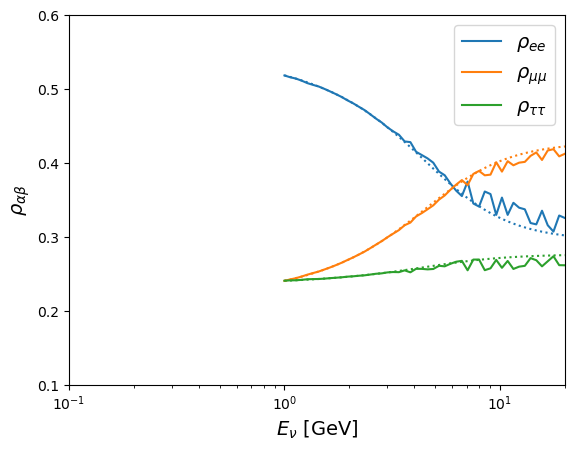

In [74]:


# Plot daytime-only solar neutrino probabilities
plt.loglog(Enuspace,abs(density_sm[:, 0,0]), ls=':', color="tab:blue")
plt.loglog(Enuspace,abs(density_sm[:, 1,1]), ls=':', color="tab:orange")
plt.loglog(Enuspace,abs(density_sm[:, 2,2]), ls=':', color="tab:green")


# Plot matter-evolved probabilities for one angle
plt.loglog(Enuspace,abs(rho_earthceta1[:, 0,0]), ls='-', label=r'$\rho_{ee}$',       color="tab:blue" )
plt.loglog(Enuspace,abs(rho_earthceta1[:, 1,1]), ls='-', label=r'$\rho_{\mu\mu}$',   color="tab:orange" )
plt.loglog(Enuspace,abs(rho_earthceta1[:, 2,2]), ls='-', label=r'$\rho_{\tau\tau}$', color="tab:green" )


plt.xlim(xmin=1e-1, xmax=2.0e1)
plt.ylim(ymin=0.1, ymax=0.6)
plt.yscale('linear')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=1)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Compute the full denisty averaged over incident angles

In [44]:
import tqdm as tqdm
from multiprocess import Pool

In [48]:
def rho_weighted_average(probevolution, rhosm, Enuspace, weights, angles):


    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)
    
    for i in tqdm.tqdm(range(len(weights))):
        ceta = np.cos(angles[i])
        # evolve through earth
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        rho_ave += weights[i] * rho_earth

    return rho_ave




def rho_weighted_average_parallel(probevolution, rhosm, Enuspace, weights, angles, nb_core=8):

    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)

    # Arg list of cross sections
    args = []
    for i , w in enumerate(weights):
        ceta = np.cos(angles[i])
        args.append((w, ceta))

    def parallel_evolve(index):
        weight, ceta = args[index]
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        return weight * rho_earth
    
    # Run the parallel evolution
    with Pool(nb_core) as pool:
        for result in tqdm.tqdm(pool.imap_unordered(parallel_evolve, range(len(args))), total=len(args), desc='Zenith angles'):
             rho_ave += result

    return rho_ave

In [75]:
# rho_ave = rho_weighted_average(PREMprob, density_sm, Enuspace, weights, angles)
rho_ave = rho_weighted_average_parallel(PREMprob, density_sm, Enuspace_gev, weights, angles)

Zenith angles: 100%|██████████| 50/50 [00:02<00:00, 21.66it/s]


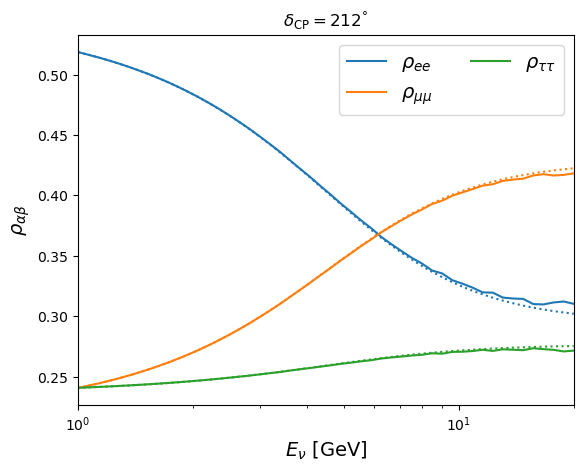

In [76]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]), ls=':', color="tab:blue" )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]), ls=':', color="tab:orange")
plt.loglog(Enuspace,abs(density_sm[:, 2,2]), ls=':', color="tab:green")

plt.loglog(Enuspace,abs(rho_ave[:, 0,0]), label=r'$\rho_{ee}$',        color="tab:blue" )
plt.loglog(Enuspace,abs(rho_ave[:, 1,1]), label=r'$\rho_{\mu\mu}$',    color="tab:orange" )
plt.loglog(Enuspace,abs(rho_ave[:, 2,2]), label=r'$\rho_{\tau\tau}$',  color="tab:green" )



plt.xlim(xmin=1e0, xmax=2.0e1)
plt.yscale('linear')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=212^\degree$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.savefig("earth_matter_prob_{}.png".format(int(len(Enuspace))), dpi=300)

To have accurate averaging, we need a sufficient density of point in the energy region ~[5, 20] MeV

## Run with old oscillation parameters

In [15]:
params_old = osc.osc_params_old

rho_sun2 = probs.DensityMatrixCalculator(sm_model, osc_params=params_old).density(Enuspace, '8B')
PREMprob2 = em.EarthProbEvolve(osc_params=params_old, model=sm_model, earthmodel=PREMmodel)



In [16]:
# rho_ave2 = rho_weighted_average(PREMprob2, rho_sun2, Enuspace, weights, angles)
rho_ave2 = rho_weighted_average_parallel(PREMprob2, rho_sun2, Enuspace, weights, angles)

Zenith angles: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

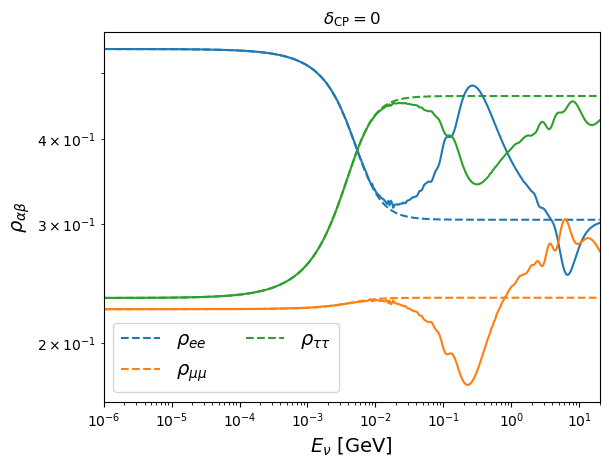

In [17]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=0$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [18]:
angles < np.pi/2

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])